# Twitter Emoji Prediction

## 1. Data Exploration

### 1.1 Load the CSV files

In [1]:
import pandas as pd


train = pd.read_csv("/kaggle/input/twitter-emoji-prediction/Train.csv")
test = pd.read_csv("/kaggle/input/twitter-emoji-prediction/Test.csv")
mapping = pd.read_csv("/kaggle/input/twitter-emoji-prediction/Mapping.csv")

print("Train Data:")
display(train.head())

print("Test Data:")
display(test.head())

print("Mapping Data:")
display(mapping.head())


Train Data:


,Unnamed: 0,TEXT,Label
0,0,Vacation wasted ! #vacation2017 #photobomb #ti...,0
1,1,"Oh Wynwood, you’re so funny! : @user #Wynwood ...",1
2,2,Been friends since 7th grade. Look at us now w...,2
3,3,This is what it looks like when someone loves ...,3
4,4,RT @user this white family was invited to a Bl...,3


Test Data:


,Unnamed: 0,id,TEXT
0,0,0,Thought this was cool...#Repost (get_repost)・・...
1,1,1,Happy 4th! Corte madera parade. #everytownusa ...
2,2,2,Luv. Or at least something close to it. @ Unio...
3,3,3,There's a slice of pie under that whipped crea...
4,5,5,#thankyou for your thank you We adore you both...


Mapping Data:


,Unnamed: 0,emoticons,number
0,0,😜,0
1,1,📸,1
2,2,😍,2
3,3,😂,3
4,4,😉,4


### 1.2 Dataset size and info

In [2]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Mapping shape:", mapping.shape)


print("Missing values in train:\n", train.isnull().sum())
print("Missing values in test:\n", test.isnull().sum())
print("Missing values in map:\n", mapping.isnull().sum())

Train shape: (70000, 3)
Test shape: (25958, 3)
Mapping shape: (20, 3)
Missing values in train:
 Unnamed: 0    0
TEXT          0
Label         0
dtype: int64
Missing values in test:
 Unnamed: 0    0
id            0
TEXT          0
dtype: int64
Missing values in map:
 Unnamed: 0    0
emoticons     0
number        0
dtype: int64


### 1.3 Explore class distribution

/tmp/ipykernel_55/1430205392.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


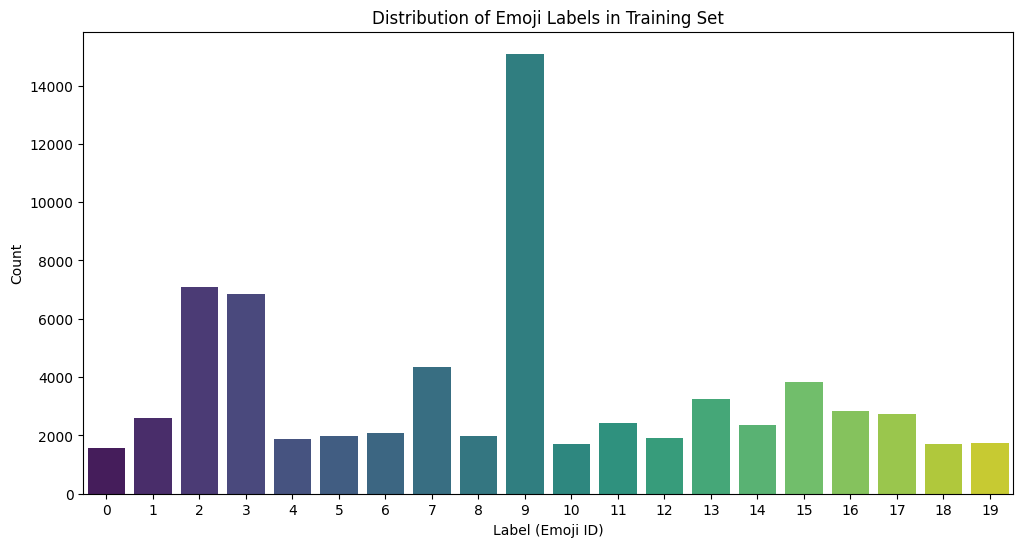

In [3]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("plots", exist_ok=True)

label_counts = train['Label'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.title("Distribution of Emoji Labels in Training Set")
plt.xlabel("Label (Emoji ID)")
plt.ylabel("Count")

plt.savefig("plots/class_distribution.png", dpi=300)
plt.show()
plt.close()

### 1.4 Tweet Length Distribution


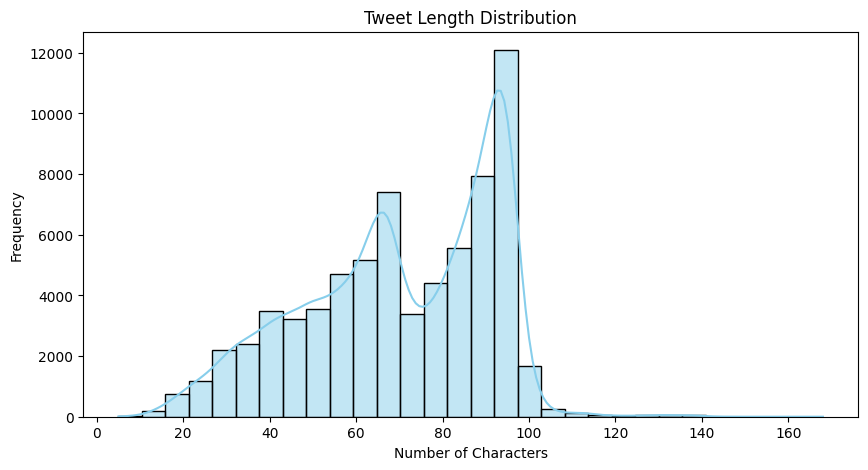

count    70000.000000
mean        70.008171
std         21.868925
min          5.000000
25%         54.000000
50%         71.000000
75%         90.000000
max        168.000000
Name: tweet_length, dtype: float64


In [4]:
train['tweet_length'] = train['TEXT'].astype(str).apply(len)


plt.figure(figsize=(10, 5))
sns.histplot(train['tweet_length'], bins=30, kde=True, color='skyblue')
plt.title("Tweet Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.savefig("plots/tweet_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(train['tweet_length'].describe())


## 2. Data Preprocessing

### 2.1 Clean Tweets

In [5]:
import re

def clean_tweet(text):
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    # Remove @mentions
    text = re.sub(r"@\w+", "", text)
    # Remove hashtags symbol (#), keep the word
    text = re.sub(r"#", "", text)
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

train['clean_text'] = train['TEXT'].apply(clean_tweet)
test['clean_text'] = test['TEXT'].apply(clean_tweet)

### 2.2 Train/Validation Split

In [6]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train['clean_text'],
    train['Label'],
    test_size=0.2,
    stratify=train['Label'],  
    random_state=42
)

### 2.3 Tokenization

In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test['clean_text']), truncation=True, padding=True, max_length=128)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

### 2.4 Pytorch Dataset

In [8]:
import torch

class TweetDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels
    
    def __len__(self):
        return len(self.encodings['input_ids'])
    
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item


train_dataset = TweetDataset(train_encodings, train_labels)
val_dataset = TweetDataset(val_encodings, val_labels)
test_dataset = TweetDataset(test_encodings) 

## 3. Transformer Model Setup and Training

### 3.1 Define the Model

In [9]:
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments
import torch
from sklearn.metrics import accuracy_score, f1_score

num_classes = train['Label'].nunique()

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_classes
)

2025-12-24 15:41:34.384197: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766590894.552454      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766590894.604389      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766590895.018937      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766590895.018983      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766590895.018986      55 computation_placer.cc:177] computation placer alr

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### 3.2 Define Metrics

In [10]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    return {"accuracy": acc, "f1": f1}

### 3.3 Training Arguments

In [11]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=7,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    logging_dir="./logs",
    logging_steps=1000,
    learning_rate=5e-5,
    save_total_limit=2,
    report_to=[]
)


### 3.4 Initialize Trainer

In [12]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

### 3.5 Train the Model

In [ ]:
device = torch.device("cuda")
model.to(device)

trainer.train()

model.save_pretrained("emoji_predictor_model")
tokenizer.save_pretrained("emoji_predictor_model")

Step,Training Loss
1000,2.247000
2000,1.894400
3000,1.574000
4000,1.268500


### 3.6 Plots

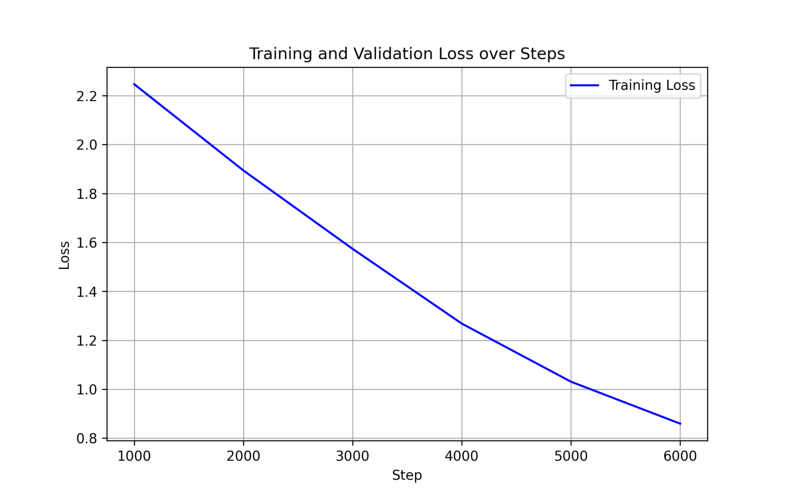

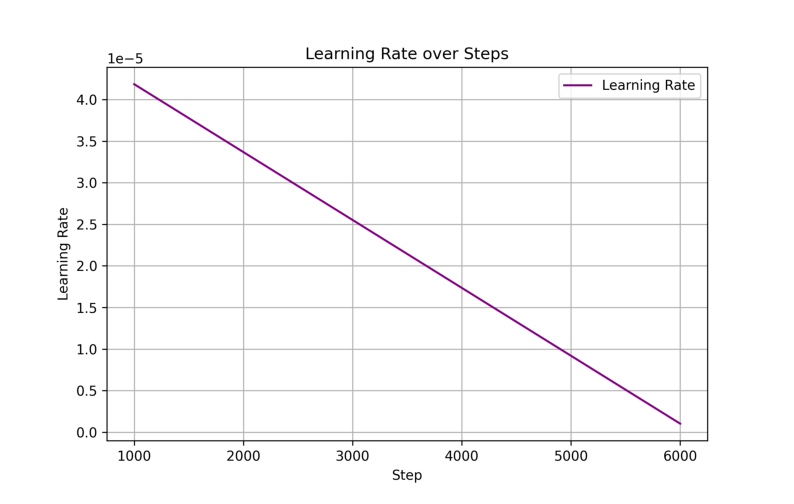

In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt

logs_df = pd.DataFrame(trainer.state.log_history)

logs_df.to_csv("plots/training_logs.csv", index=False)



plt.figure(figsize=(8,5))
if 'loss' in logs_df.columns:
    plt.plot(logs_df['step'], logs_df['loss'], label='Training Loss', color='blue')
if 'eval_loss' in logs_df.columns:
    plt.plot(logs_df['step'], logs_df['eval_loss'], label='Validation Loss', color='red')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Steps')
plt.legend()
plt.grid(True)
plt.savefig("plots/loss_curve.png", dpi=300)
plt.show()
plt.close()


if 'learning_rate' in logs_df.columns:
    plt.figure(figsize=(8,5))
    plt.plot(logs_df['step'], logs_df['learning_rate'], label='Learning Rate', color='purple')
    plt.xlabel('Step')
    plt.ylabel('Learning Rate')
    plt.title('Learning Rate over Steps')
    plt.legend()
    plt.grid(True)
    plt.savefig("plots/lr_curve.png", dpi=300)
    plt.show()
    plt.close()


### 3.7 Confusion Matrix

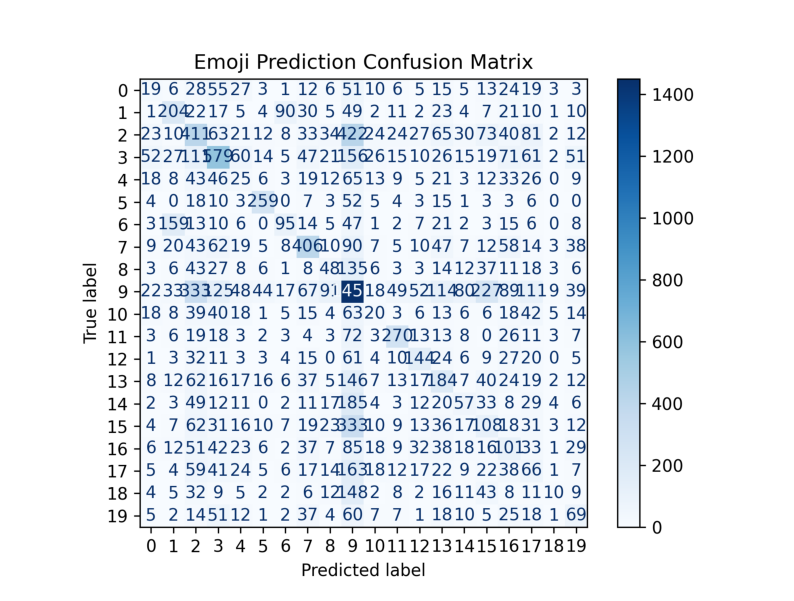

In [19]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32)

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


cm = confusion_matrix(all_labels, all_preds)


plt.figure(figsize=(12,10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, colorbar=True)
plt.title("Emoji Prediction Confusion Matrix")
plt.savefig("plots/confusion_matrix.png", dpi=300)
plt.close()


## 4. Generate Test Set Predictions

### 4.1 Load model & tokenizer

In [21]:
from transformers import DistilBertForSequenceClassification, AutoTokenizer
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DistilBertForSequenceClassification.from_pretrained("emoji_predictor_model")
tokenizer = AutoTokenizer.from_pretrained("emoji_predictor_model")

model.to(device)
model.eval()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


### 4.2 Create DataLoader for Test Set

In [22]:
from torch.utils.data import DataLoader

test_loader = DataLoader(test_dataset, batch_size=32)

### 4.3 Run Inference on Test Data

In [23]:
all_test_preds = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)

        all_test_preds.extend(preds.cpu().numpy())

### 4.4 Convert Labels to Emojis

In [24]:
num_to_emoji = dict(zip(mapping['number'], mapping['emoticons']))

test_emojis = [num_to_emoji[p] for p in all_test_preds]

### 4.5 Create Final Prediction File

In [25]:
submission = test[['id']].copy()
submission['Label'] = test_emojis

submission.head()

,id,Label
0,0,📸
1,1,🇺🇸
2,2,❤
3,3,❤
4,5,✨


In [26]:
submission.to_csv("test_predictions.csv", index=False)
print("Saved test predictions to test_predictions.csv")

Saved test predictions to test_predictions.csv
